# SOM evaluation of mean redshifts

This notebook evaluates the pre-trained PAE as a galaxy population prior for photometric-redshift calibration ([Frediani et al. 2026](https://arxiv.org/abs/2609.26594), Sect. 3.4):
synthetic $ugriZYJHK_s$ photometry is computed for the simulated test set and for a PAE-generated sample, both are sorted into the pre-trained DC3R2 self-organising map, and the induced bias from the learned model is evaluated on the mean redshifts of colour-selected tomographic bins.
Reproduces Figs. 7–8, C.1 and D.1 and Table 1 of the paper.
A GPU is recommended.

In [ ]:
import numpy as np
import torch
import matplotlib as mpl
from matplotlib import pyplot as plt
import corner
from sklearn.model_selection import train_test_split
import time
import os

print('CUDA is available:',torch.cuda.is_available())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
FILEPATH = './'
DATAPATH = 'datasets/'
os.chdir(FILEPATH)

import models
import util
import SOM

CUDA is available: True


## Simulated test sample

Load the GalSBI-SPS spectra and redshifts, keep the seeded test split (identical to
the training scripts), and transform to the observed frame:
$\lambda_\mathrm{obs} = (1+z)\,\lambda_\mathrm{rest}$, with $f_\lambda$ scaled
by $1/(1+z)$ to conserve flux.

In [2]:
Z_MAX = 1.55  # redshift cut of the simulated sample
WAV = torch.logspace(np.log10(1000), np.log10(25000), 2000)  # rest-frame wavelength grid

raw_spectra = torch.load(DATAPATH+'sim_sample_sed.pt')
z = torch.load(DATAPATH+'sim_sample_z.pt')

idx_train, idx_test = train_test_split(torch.arange(len(raw_spectra)), train_size=int(1e6), random_state=151)
idx_test,  idx_val  = train_test_split(idx_test,                  train_size=int(1e6), random_state=151)
print('train:', len(idx_train), '  test:', len(idx_test), '  val:', len(idx_val))

# keep only the test split, then transform to the observed frame:
# wavelengths stretch by (1+z), flux density scales by 1/(1+z)
z = z[idx_test]
obs_wav = WAV * (1+z[:,None])
obs_raw_spectra = raw_spectra[idx_test].div_(1+z[:,None])
del raw_spectra

train: 1000000   test: 1000000   val: 305000


### PAE-generated sample

One realisation of $10^6$ galaxies sampled from the PAE (generated in
`1_SED_model.ipynb`). The luminosity is recovered from the flow-space variable $l^*$,
and the spectra are shifted to the observed frame like the simulations.

In [3]:
# PAE generated spectra
gen_spectra = torch.load(DATAPATH+'PAE_sample_sed.pt')[:len(idx_test)]
gen_z = torch.load(DATAPATH+'PAE_sample_z.pt')[:len(idx_test)]
gen_L = torch.load(DATAPATH+'PAE_sample_L.pt')[:len(idx_test)]

gen_wav = WAV * (1+gen_z[:,None])
gen_obs_spectra = gen_spectra / (1+gen_z[:,None])
gen_L = 10**gen_L / 1e17  # invert the flow-space transform l* = log10(L* * 1e17)
gen_obs_spectra *= gen_L[:,None]


## Pseudo-photometry

Calculate AB magnitudes by integrating over $ugriZYJHK_s$ filters and add Gaussian flux noise matched to COSMOS2015 depths, to better match the photometry imprinted on the
SOM through its training data.

In [4]:

def add_COSMOS_like_noise(raw_mags):
    """Perturb AB magnitudes with COSMOS2015-depth Gaussian flux noise.
    Bands without a 3 sigma detection are flagged and set to the limiting magnitude."""
    # COSMOS2015 reported depth from Laigle et al. (2016), 
    # Table 1, 3" aperture, 3 sigma limit, UD for VISTA VIRCAM
    # Subaru Suprime-Cam uses B,V filters, g here is average of those two
    COSMOS_depth = {'u': 26.6, 
                    'g': (27.0+26.2)/2, 
                    'r': 26.5, 
                    'i': 26.2, 
                    'z': 25.9, 
                    'Y': 25.3, 
                    'J': 24.9, 
                    'H': 24.6, 
                    'K': 24.7}

    COSMOS_flim = {band: util.mag_to_flux(depth) for band, depth in COSMOS_depth.items()} # limiting flux
    COSMOS_sigma = {band: flux / 3 for band, flux in COSMOS_flim.items()} # 3 sigma limit

    mags = {band: util.flux_to_mag(util.mag_to_flux(raw_mags[band]) + COSMOS_sigma[band] * torch.randn(size=raw_mags[band].shape))
            for band in raw_mags}
    non_detections = {band: (util.mag_to_flux(mags[band]) < 3 * COSMOS_sigma[band]) | mags[band].isnan() 
                      for band in raw_mags}
    mags = {band: mags[band].masked_fill(non_detections[band], COSMOS_depth[band]) 
            for band in raw_mags}
    mag_errs = {band: 2.5/np.log(10)/util.mag_to_flux(mags[band]) * COSMOS_sigma[band] 
                for band in raw_mags}
    return mags, mag_errs, non_detections



def calculate_colors(mags, mag_errs, non_detections, 
                     color_pairs = [('u','g'),('g','r'),('r','i'),('i','z'),('z','Y'),('Y','J'),('J','H'),('H','K')]):
    """Adjacent-band colours, their variances, and non-detection flags
    (+1 / -1 / NaN, see below) from per-band magnitudes."""
    colors = []
    color_vars = []
    limit_type = []

    for k1,k2 in color_pairs:
        colors.append(mags[k1] - mags[k2])
        color_vars.append(mag_errs[k1]**2 + mag_errs[k2]**2)
        # flag colours affected by non-detections, for the SOM distance metric:
        #  +1: k1 undetected -> its magnitude is a lower limit -> the colour k1-k2
        #      is a lower limit, i.e. the true colour cannot be bluer
        #  -1: k2 undetected -> the colour is an upper limit, cannot be redder
        # NaN: both undetected -> the colour carries no information and is skipped
        bad_color = torch.zeros(len(mags[k1]))
        bad_color[non_detections[k1] & ~non_detections[k2]] = 1
        bad_color[~non_detections[k1] & non_detections[k2]] = -1
        bad_color[non_detections[k1] & non_detections[k2]] = torch.nan
        limit_type.append(bad_color)

    colors = torch.from_numpy(np.array(colors)).T.float()
    color_vars = torch.from_numpy(np.array(color_vars)).T.float()
    limit_type = torch.from_numpy(np.array(limit_type)).T
    return colors, color_vars, limit_type

In [5]:
# compute magnitudes
raw_mags = util.ab_mag(obs_raw_spectra, obs_wav, bands='ugrizYJHK')

# add noise
mags, mag_errs, non_detections = add_COSMOS_like_noise(raw_mags)

# calculate colors
colors, color_vars, limit_type = calculate_colors(mags, mag_errs, non_detections)


# PAE generated sample
gen_raw_mags = util.ab_mag(gen_obs_spectra, gen_wav, bands='ugrizYJHK')
gen_mags, gen_mag_errs, gen_non_detections = add_COSMOS_like_noise(gen_raw_mags)
gen_colors, gen_color_vars, gen_limit_type = calculate_colors(gen_mags, gen_mag_errs, gen_non_detections)


### Colour distributions

Corner plot of the PAE-generated and simulated colour spaces (Fig. C.1).

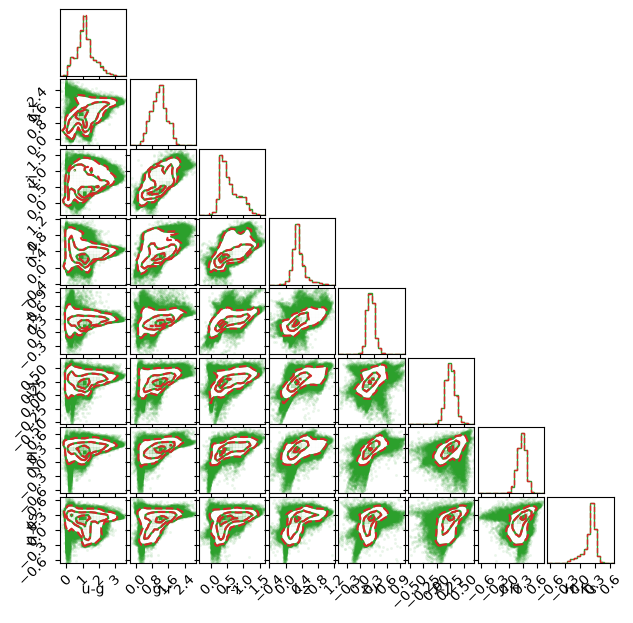

In [6]:
# compare color distributions of simulations and model
levels = [(1-np.exp(-s**2/2)) for s in (1,2,3,)]
color_ranges = [(l.item()-0.1*(u.item()-l.item()),u.item()+0.1*(u.item()-l.item())) for l,u in np.quantile(colors,[0.0001,0.9999],axis=0).T]
color_labels = ['u-g','g-r','r-i','i-z','z-Y','Y-J','J-H','H-Ks']
fig = plt.figure(figsize=(6,6))
corner.corner(gen_colors.numpy(), fig=fig, color='tab:green',
            levels=levels, range=color_ranges, labels=color_labels,)
corner.corner(colors.numpy(), fig=fig, color='tab:red', contour_kwargs={'linestyles':'dashed'}, hist_kwargs={'linestyle':'dashed'},
            levels=levels, range=color_ranges, labels=color_labels,
            plot_datapoints=False, plot_density=False, no_fill_contours=True)
plt.show()

## The C3R2 SOM

The pre-trained 75×150-cell C3R2 SOM maps the 8-dimensional colour space; each cell
also carries a nominal photometric redshift, used below to identify cells beyond the
sample's redshift cut.

In [7]:

som = SOM.SOM(map_dims=(75,150), feature_dim=8)

som.load_weights(path=DATAPATH+"SOM_weights.txt",
                 columns=(4, 5, 6, 7, 8, 9, 10, 11))

nominal_redshift = torch.from_numpy(np.genfromtxt(DATAPATH+"SOM_weights.txt")[:,12])

## Assigning galaxies to SOM cells

Each galaxy is matched to its best matching unit under the reduced-$\chi^2$ distance. The assignments yield cell occupancies and per-cell mean redshifts for both samples, plus the cell-coverage statistics quoted in Sect. 3.4.

In [8]:
# assign galaxies to SOM cells
assignments = som.find_bmu(colors,color_vars,limits=limit_type)
occupancy = torch.bincount(assignments.to(torch.long), minlength=som.codebook.shape[0]).reshape((som.map_dims[1],som.map_dims[0]))

mean_z = torch.zeros(som.codebook.shape[0]) * torch.nan
for i in range(som.codebook.shape[0]):
    cell_members = (assignments == i).nonzero(as_tuple=True)[0]
    if len(cell_members) > 0:
        mean_z[i] = z[cell_members].mean()
    else:
        mean_z[i] = torch.nan


print(f'filling fraction: {(occupancy > 0).sum().item() / occupancy.numel():.2%}')
print(f'filling fraction high-z corrected: {((occupancy.flatten()[nominal_redshift<Z_MAX] > 0).sum().item() / occupancy.flatten()[nominal_redshift<Z_MAX].numel()):.2%}')
print(f'>10 filling fraction high-z corrected: {((occupancy.flatten()[nominal_redshift<Z_MAX] > 10).sum().item() / occupancy.flatten()[nominal_redshift<Z_MAX].numel()):.2%}')



# PAE generated sample
gen_assignments = som.find_bmu(gen_colors,gen_color_vars,limits=gen_limit_type)
gen_occupancy = torch.bincount(gen_assignments.to(torch.long), minlength=som.codebook.shape[0]).reshape((som.map_dims[1],som.map_dims[0]))

gen_mean_z = torch.zeros(som.codebook.shape[0]) * torch.nan
for i in range(som.codebook.shape[0]):
    cell_members = (gen_assignments == i).nonzero(as_tuple=True)[0]
    if len(cell_members) > 0:
        gen_mean_z[i] = gen_z[cell_members].mean()
    else:
        gen_mean_z[i] = torch.nan


print('no of cells filled by PAE but not GalSBI:', ((gen_occupancy > 0) & (occupancy == 0)).sum().item())
print('no of cells filled by GalSBI but not PAE:', ((gen_occupancy == 0) & (occupancy > 0)).sum().item())
print('no of cells filled by both:', ((gen_occupancy > 0) & (occupancy > 0)).sum().item())

filling fraction: 30.63%
filling fraction high-z corrected: 39.13%
>10 filling fraction high-z corrected: 22.08%
no of cells filled by PAE but not GalSBI: 450
no of cells filled by GalSBI but not PAE: 384
no of cells filled by both: 3062


### SOM maps

Relative occupancy deviation between the PAE and simulated samples (cells occupied by
only one of the two are marked black), and the map of mean PAE redshift per cell (Fig. D.1).

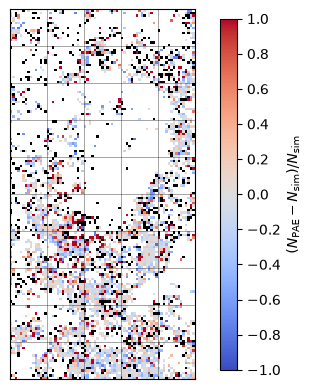

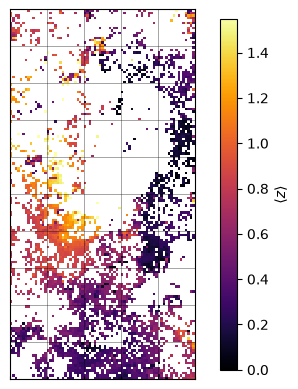

In [9]:

xe, ye = np.arange(som.map_dims[0] + 1), np.arange(som.map_dims[1] + 1)

fig, ax = plt.subplots()
im = ax.pcolormesh(xe, ye, (gen_occupancy - occupancy) / occupancy,
                   vmin=-1, vmax=1, cmap='coolwarm', shading='flat')
mask = (occupancy == 0) ^ (gen_occupancy == 0)
ax.pcolormesh(xe, ye, np.ma.masked_where(~mask, np.ones_like((gen_occupancy - occupancy) / occupancy)),
              cmap=mpl.colors.ListedColormap(['k']), vmin=0, vmax=1, shading='flat')
plt.colorbar(im, label=r"$(N_\mathrm{PAE} - N_\mathrm{sim}) / N_\mathrm{sim}$", ticks=np.arange(-1,1+1e-6,0.2), shrink=0.95)

ax.set_aspect('equal')
ax.set_xlim(0, som.map_dims[0]); ax.set_ylim(0, som.map_dims[1])
ax.set_xticks(np.arange(0, som.map_dims[0]+1, 15), [])
ax.set_yticks(np.arange(0, som.map_dims[1]+1, 15), [])
ax.grid(axis='both', which='both', color='k', linestyle='-', linewidth=0.5, alpha=0.5)
ax.tick_params(bottom=True, top=False, left=False, right=False, direction='in', length=2)
ax.set_xlim(0, som.map_dims[0])
ax.set_ylim(0, som.map_dims[1])
plt.show()


fig, ax = plt.subplots()
im = ax.pcolormesh(xe, ye, gen_mean_z.reshape((som.map_dims[1],som.map_dims[0])).numpy(),
                   vmin=0, vmax=Z_MAX, cmap='inferno', shading='flat')
plt.colorbar(im, label=r"$\langle z \rangle$", shrink=0.95)

ax.set_aspect('equal')
ax.set_xlim(0, som.map_dims[0]); ax.set_ylim(0, som.map_dims[1])
ax.set_xticks(np.arange(0, som.map_dims[0]+1, 15), [])
ax.set_yticks(np.arange(0, som.map_dims[1]+1, 15), [])
ax.grid(axis='both', which='both', color='k', linestyle='-', linewidth=0.5, alpha=0.5)
ax.tick_params(bottom=True, top=False, left=False, right=False, direction='in', length=2)
ax.set_xlim(0, som.map_dims[0])
ax.set_ylim(0, som.map_dims[1])
plt.show()


### Per-cell mean-redshift deviations

Distribution of $\langle z\rangle_\mathrm{PAE} - \langle z\rangle_\mathrm{sim}$
per cell, unweighted and weighted by cell occupancy (Fig. 7).

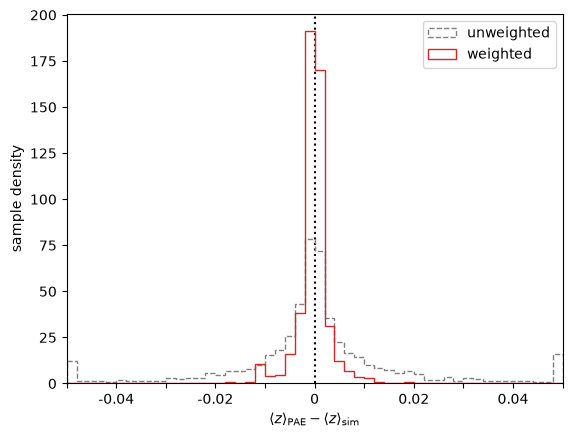

occupancy-weighted mean delta_z: -0.00023618848354090005
frac of cells with |delta_z| > 0.01: 0.31776616590463747
occupancy-weighted frac of cells with |delta_z| > 0.01: 0.04376768693327904


In [10]:
plt.figure()
plt.axvline(0, color='k', ls=':')
plt.hist((gen_mean_z-mean_z).clip(-0.05,0.05), bins=50, range=(-0.05,0.05), histtype='step', color='tab:grey', label='unweighted', linestyle='--', 
         density=True)

plt.hist((gen_mean_z-mean_z).clip(-0.05,0.05), bins=50, range=(-0.05,0.05), histtype='step', color='tab:red', label='weighted', 
         weights=occupancy.flatten()/occupancy.sum(), density=True)
plt.xlim(-0.05,0.05)
plt.xticks(np.arange(-0.05, 0.06, 0.01),['','-0.04','','-0.02','','0','','0.02','','0.04',''])
plt.xlabel(r"$\langle z \rangle_{\mathrm{PAE}} - \langle z \rangle_{\mathrm{sim}}$")
plt.ylabel(r"sample density")
plt.legend()
plt.show()

delta_z = gen_mean_z - mean_z
valid = ~delta_z.isnan()
occ = occupancy.flatten()[valid]   # occupancy of the cells populated by both samples
outlier = delta_z[valid].abs() > 0.01
print('occupancy-weighted mean delta_z:', ((delta_z[valid] * occ).sum() / occ.sum()).item())
print('frac of cells with |delta_z| > 0.01:', outlier.sum().item() / valid.sum().item())
print('occupancy-weighted frac of cells with |delta_z| > 0.01:', (occ / occ.sum())[outlier].sum().item())

## Tomographic bins

SOM cells are sorted by mean simulated redshift and filled into 5 tomographic bins of
equal galaxy count. The cell-to-bin assignment is fixed once and used identically for
both samples.

In [11]:
# split SOM cells into 5 equal-count tomographic bins, filling in order of
# ascending mean simulated redshift; the loop may append a trailing empty bin,
# only the first 5 are used
sorted_cells = torch.argsort(mean_z.flatten())

cum_sum = 0
j = 0
tomo_bins = [torch.zeros_like(occupancy.flatten(), dtype=bool)]
tomo_idx = [[]]
for i in sorted_cells:
    cum_sum += occupancy.flatten()[i]
    tomo_idx[j].append(i.item())
    tomo_bins[j][i] = True
    if cum_sum >= len(colors)/5:
        j += 1
        cum_sum = 0
        tomo_idx.append([])
        tomo_bins.append(torch.zeros_like(occupancy.flatten(), dtype=bool))


### Redshift distributions per bin

$n(z)$ of the PAE sample (occupancy-reweighted) versus the simulations in each
tomographic bin, with the bin mean redshifts (Fig. 8). The printed table corresponds
to Table 1 of the paper.

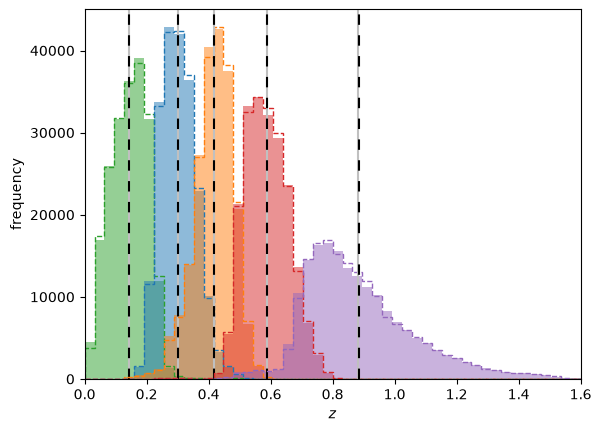

bin 	 <z_sim> 	 <z_PAE> 	 d<z>/(1+<z>)
1 	 0.14370161 	 0.14321965 	 -0.00042141
2 	 0.30195475 	 0.30170730 	 -0.00019006
3 	 0.41682741 	 0.41578072 	 -0.00073875
4 	 0.58705342 	 0.58706939 	 0.00001007
5 	 0.88324469 	 0.88389528 	 0.00034546


In [12]:

# per-cell reweighting of gen sample: N_true / N_gen
cell_weights = occupancy.flatten().float() / gen_occupancy.flatten().float()
cell_weights = torch.nan_to_num(cell_weights, nan=0.0, posinf=0.0)
w_all_gen = cell_weights[gen_assignments.long()]
cs = ['tab:green', 'tab:blue', 'tab:orange', 'tab:red', 'tab:purple']

plt.figure()
for t, c in zip(tomo_bins, cs):
    mask_true = t[assignments]
    mask_gen  = t[gen_assignments]
    w_gen = w_all_gen[mask_gen].numpy()

    plt.hist(gen_z[mask_gen], bins=50, range=(0, 1.6),
                 weights=w_gen, histtype='bar', color=c, alpha=0.5)
    plt.hist(z[mask_true], bins=50, range=(0, 1.6),
                 histtype='step', linestyle='--', color=c)

    plt.axvline(np.nanmean(z[mask_true]), color='silver', ls='-')
    plt.axvline(np.average(gen_z[mask_gen].numpy(), weights=w_gen), color='k', ls=(0, (5,5)))
plt.xlim(0, 1.6)
plt.xlabel(r"$z$"), plt.ylabel(r"frequency")
plt.show()



# per-cell reweighting of gen sample: N_true / N_gen
print('bin \t <z_sim> \t <z_PAE> \t d<z>/(1+<z>)')
for i, t in enumerate(tomo_bins):
    mask_true = t[assignments]
    mask_gen  = t[gen_assignments]
    w_gen  = w_all_gen[mask_gen].numpy()
    mz     = np.nanmean(z[mask_true])
    gen_mz = np.average(gen_z[mask_gen].numpy(), weights=w_gen)
    print(f'{i+1} \t {mz:.8f} \t {gen_mz:.8f} \t {(gen_mz - mz) / (1 + mz):.8f}')


## PAE sample variance

Sample variance of the mean redshift for bins of 200,000 galaxies becomes statistically significant for very good agreement. A naive estimate shows that the inherent scatter is of the order of the overall model bias. Repeatedly sampling PAE realisations suppresses the scatter of the generated sample (the scatter of the test and training sets remains).

In [13]:
# naively estimate inherent scatter
for i,t in enumerate(tomo_bins):
    print(f'bin {i+1} \t std: {z[t[assignments]].std():.3f} \t n: {z[t[assignments]].shape[0]} \t std of mean: {z[t[assignments]].std() / np.sqrt(z[t[assignments]].shape[0]):.5f}')


bin 1 	 std: 0.059 	 n: 200566 	 std of mean: 0.00013
bin 2 	 std: 0.056 	 n: 207011 	 std of mean: 0.00012
bin 3 	 std: 0.063 	 n: 206847 	 std of mean: 0.00014
bin 4 	 std: 0.070 	 n: 205737 	 std of mean: 0.00015
bin 5 	 std: 0.177 	 n: 179839 	 std of mean: 0.00042


In [14]:
# repeat the full sampling -> photometry -> SOM -> binning pipeline N_REP times

bin_dz = [[],[],[],[],[]]
bin_mz = [[],[],[],[],[]]

autoenc = models.build_paper_autoencoder()
autoenc = models.LAutoencoder.load_from_checkpoint(FILEPATH+'models/AE_n6_enc1000x500x100_ReLU_asinh-sinh_noise0.1_Adam_lr0.001_reduce_1000k_GalSBIUspec1M_restframe/version_0/best.ckpt', 
                                              model=autoenc).to(device)
N_LATENT = 6
flow = models.build_paper_flow()
flow = models.LFlow.load_from_checkpoint(FILEPATH + 'models/Flow_MAF_t5_h256x256x256_Adam_lr0.001_reduce_1000k_GalSBIUspec1M_restframe/version_0/best.ckpt',
    model=flow).eval().to(device)

N_REP = 100
tic = time.time()
for j in range(N_REP):
    samples = flow(None).sample((1000000,))
    with torch.no_grad():
        gen_spectra = autoenc.model.decode(samples[:, :N_LATENT])
    gen_z = samples[:, N_LATENT].detach()
    gen_L = samples[:, N_LATENT+1].detach()

    gen_wav = WAV.to(gen_z.device) * (1+gen_z[:,None])
    gen_L = 10**gen_L / 1e17
    gen_obs_spectra = gen_spectra.div_(1+gen_z[:,None]).mul_(gen_L[:,None])

    gen_raw_mags = util.ab_mag(gen_obs_spectra, gen_wav, bands='ugrizYJHK')
    del gen_spectra, gen_obs_spectra, gen_wav   # free GPU memory before the SOM assignment
    gen_mags, gen_mag_errs, gen_non_detections = add_COSMOS_like_noise(gen_raw_mags)
    gen_colors, gen_color_vars, gen_limit_type = calculate_colors(gen_mags, gen_mag_errs, gen_non_detections)

    gen_assignments = som.find_bmu(gen_colors,gen_color_vars,limits=gen_limit_type)
    gen_occupancy = torch.bincount(gen_assignments.to(torch.long), minlength=som.codebook.shape[0]).reshape((som.map_dims[1],som.map_dims[0]))

    cell_weights = occupancy.flatten().float() / gen_occupancy.flatten().float()
    cell_weights = torch.nan_to_num(cell_weights, nan=0.0, posinf=0.0)
    w_all_gen = cell_weights[gen_assignments.long()]

    for i, t in enumerate(tomo_bins):
        mask_true = t[assignments]
        mask_gen  = t[gen_assignments]
        w_gen  = w_all_gen[mask_gen].numpy()
        mz     = np.nanmean(z[mask_true])
        gen_mz = np.average(gen_z[mask_gen].cpu().detach().numpy(), weights=w_gen)
        bin_dz[i].append((gen_mz - mz) / (1 + mz))
        bin_mz[i].append(gen_mz)
    print(f'PAE resampling iteration {j+1}/{N_REP}     ETA: {(time.time() - tic) / (j+1) * (N_REP-(j+1)) :.2f}s',end='\r')

print(f'mean d<z>/(1+<z>) \t {np.array(bin_dz).mean(axis=1)}')
print(f'std d<z>/(1+<z>) \t {np.array(bin_dz).std(axis=1)}')
print(f'mean <z> \t {np.array(bin_mz).mean(axis=1)}')
print(f'std <z> \t {np.array(bin_mz).std(axis=1)}')

mean d<z>/(1+<z>) 	 [-3.9144710e-04 -1.7729336e-04 -6.5506366e-04 -2.0992749e-05
  3.6895927e-04]
std d<z>/(1+<z>) 	 [4.5792727e-05 6.2962361e-05 8.0837475e-05 6.0409595e-05 7.8028104e-05]
mean <z> 	 [0.14325391 0.3017239  0.41589928 0.5870201  0.8839395 ]
std <z> 	 [5.2373205e-05 8.1974147e-05 1.1453275e-04 9.5873256e-05 1.4694601e-04]
